# BMA — Kaggle Setup, Corpus EDA, and Reproducible Runtime (Phases 0–2)

This notebook is ready to run in Kaggle with **Run All**. It clones or updates the public repository, installs the local `doc_agent` package, verifies the environment and GPU, discovers attached PDF inputs, loads the project configuration, and writes a smoke-test artifact.

Before running, attach the two source PDFs as a **private Kaggle dataset**. The notebook discovers PDFs anywhere under `/kaggle/input`, so the Kaggle dataset slug does not need to be hard-coded.

In [1]:
# Configuration — normally no edits are required.
from pathlib import Path

REPO_URL = "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git"
REPO_BRANCH = "fahim"  # Phase branch; change to main after the PR is merged.
REPO_DIR = Path("/kaggle/working/doc-agent-20")
KAGGLE_INPUT = Path("/kaggle/input")
ARTIFACT_DIR = Path("/kaggle/working/artifacts")

print("Repository:", REPO_URL)
print("Branch:", REPO_BRANCH)
print("Working copy:", REPO_DIR)
print("Kaggle inputs:", KAGGLE_INPUT)


Repository: https://github.com/FAHIM-ISHTIAK/doc-agent-20.git
Branch: fahim
Working copy: /kaggle/working/doc-agent-20
Kaggle inputs: /kaggle/input


## 1. Inspect the Kaggle runtime

In [2]:
import os
import platform
import subprocess
import sys

print("Python:", sys.version.replace("\n", " "))
print("Platform:", platform.platform())
print("Current directory:", Path.cwd())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    if torch.cuda.is_available():
        print("GPU count:", torch.cuda.device_count())
        for gpu_index in range(torch.cuda.device_count()):
            print(f"GPU {gpu_index}:", torch.cuda.get_device_name(gpu_index))
    else:
        print("WARNING: No GPU detected. In Kaggle, open Settings -> Accelerator and select a GPU.")
except Exception as exc:
    print("PyTorch inspection failed:", repr(exc))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Current directory: /kaggle/working
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Clone or update the repository

The cell is safe to run again. If a clean Git checkout already exists, it updates `main` with a fast-forward pull. It does not delete or overwrite an unrelated directory.

In [3]:
def run_command(command, cwd=None):
    print("$", " ".join(map(str, command)))
    completed = subprocess.run(
        [str(part) for part in command],
        cwd=str(cwd) if cwd else None,
        check=True,
        text=True,
        capture_output=True,
    )
    if completed.stdout.strip():
        print(completed.stdout.strip())
    if completed.stderr.strip():
        print(completed.stderr.strip())
    return completed

if REPO_DIR.exists():
    if not (REPO_DIR / ".git").is_dir():
        raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository. Choose a different REPO_DIR.")
    print("Existing repository found; updating it.")
    run_command(["git", "fetch", "origin"], cwd=REPO_DIR)
    run_command(["git", "switch", REPO_BRANCH], cwd=REPO_DIR)
    run_command(["git", "pull", "--ff-only", "origin", REPO_BRANCH], cwd=REPO_DIR)
else:
    print("Cloning repository.")
    run_command(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)])

commit_hash = run_command(["git", "rev-parse", "HEAD"], cwd=REPO_DIR).stdout.strip()
status = run_command(["git", "status", "--short"], cwd=REPO_DIR).stdout.strip()
print("Tested commit:", commit_hash)
print("Working tree:", "clean" if not status else status)


Cloning repository.
$ git clone --branch fahim https://github.com/FAHIM-ISHTIAK/doc-agent-20.git /kaggle/working/doc-agent-20
Cloning into '/kaggle/working/doc-agent-20'...
$ git rev-parse HEAD
bbe2cdebb9208469a4cdf62cda8e400d2d286e98
$ git status --short
Tested commit: bbe2cdebb9208469a4cdf62cda8e400d2d286e98
Working tree: clean


## 3. Install the repository package

This smoke test installs the local package without resolving the full ML dependency stack. Phase 2 will finalize and pin the complete Kaggle dependency environment.

In [4]:
run_command(
    [sys.executable, "-m", "pip", "install", "-r", str(REPO_DIR / "requirements.lock")]
)
run_command(
    [sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR), "--no-deps"]
)

# Add src explicitly as a robust notebook-session fallback after editable installation.
src_dir = REPO_DIR / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

os.chdir(REPO_DIR)
print("Current directory:", Path.cwd())
print("Source directory on sys.path:", str(src_dir) in sys.path)


$ /usr/bin/python3 -m pip install pymupdf>=1.24,<1.27 pillow>=10.3,<12.0 pyyaml>=6.0,<7.0 pydantic>=2.7,<3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 75.0 MB/s eta 0:00:00
$ /usr/bin/python3 -m pip install -e /kaggle/working/doc-agent-20 --no-deps
Obtaining file:///kaggle/working/doc-agent-20
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for doc-agent (pyproject.toml): started
  Building editable for doc-agent (pyproject.toml): finished with status 'done'
  Created wheel for doc-agent: filename=doc_agent-0.1.

## 4. Import `doc_agent` and load its fixed contracts

In [5]:
import importlib.util

package_spec = importlib.util.find_spec("doc_agent")
print("doc_agent module specification:", package_spec)
if package_spec is None:
    raise ModuleNotFoundError("doc_agent is still unavailable after editable installation")

import doc_agent
from doc_agent import config
from doc_agent.contracts import Chunk, Page, Region

cfg = config.load(REPO_DIR / "configs" / "config.yaml")
task_cfg = config.load_task(REPO_DIR / "configs" / "task.yaml")

print("doc_agent imported from:", Path(doc_agent.__file__).resolve())
print("Configuration loaded successfully:")
print(cfg)
print("Task configuration loaded successfully:")
print(task_cfg)
print("Contracts:", Page.__name__, Region.__name__, Chunk.__name__)
print("IMPORT SMOKE TEST: PASS")


doc_agent module specification: ModuleSpec(name='doc_agent', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7adbaaedd160>, origin='/kaggle/working/doc-agent-20/src/doc_agent/__init__.py', submodule_search_locations=['/kaggle/working/doc-agent-20/src/doc_agent'])
doc_agent imported from: /kaggle/working/doc-agent-20/src/doc_agent/__init__.py
Configuration loaded successfully:
{'seed': 42, 'device': 'cuda', 'data': {'raw_dir': 'data/raw', 'interim_dir': 'data/interim', 'artifact_dir': 'artifacts', 'render_dpi': 300, 'split_by': 'document'}, 'preprocess': {'deskew': True, 'denoise': True, 'binarize': True, 'preserve_originals': True}, 'enhance': {'enabled': False, 'model': None, 'type': 'none'}, 'layout': {'model': 'heuristic-baseline', 'score_thr': 0.5, 'reading_order': 'top-to-bottom-left-to-right'}, 'ocr': {'model': 'easyocr:bn', 'finetune': False, 'unicode_normalization': 'NFC', 'preserve_raw_text': True, 'vlm_fallback': {'enabled': False, 'model': 'Qwen/Qwen2.5-VL-7B

## 5. Discover attached corpus PDFs

The PDFs may live under any private Kaggle input dataset. This cell searches all of `/kaggle/input`.

In [6]:
if not KAGGLE_INPUT.exists():
    raise FileNotFoundError("/kaggle/input does not exist. This notebook is intended to run in Kaggle.")

pdf_files = sorted(KAGGLE_INPUT.rglob("*.pdf"))
print(f"Found {len(pdf_files)} PDF file(s) under {KAGGLE_INPUT}:")
for pdf_path in pdf_files:
    size_mb = pdf_path.stat().st_size / (1024 * 1024)
    print(f"- {pdf_path} ({size_mb:.2f} MB)")

if len(pdf_files) < 2:
    raise FileNotFoundError(
        "Expected the two BMA source PDFs. Attach the private corpus dataset to this Kaggle notebook and run again."
    )

print("CORPUS DISCOVERY: PASS")


Found 2 PDF file(s) under /kaggle/input:
- /kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf (25.48 MB)
- /kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf (136.51 MB)
CORPUS DISCOVERY: PASS


## 6. Validate the fixed data contracts

In [7]:
sample_page = Page(
    id="smoke_page_0001",
    image_path="/kaggle/working/example.png",
    doc_id="smoke_document",
)
sample_region = Region(
    page_id=sample_page.id,
    bbox=(0, 0, 100, 100),
    kind="text",
)
sample_chunk = Chunk(
    id="smoke_chunk_0001",
    doc_id=sample_page.doc_id,
    text="বাংলা ব্যাকরণ",
    page_ids=[sample_page.id],
)

print(sample_page.model_dump())
print(sample_region.model_dump())
print(sample_chunk.model_dump())
assert sample_chunk.text == "বাংলা ব্যাকরণ"
assert sample_chunk.page_ids == [sample_page.id]
print("CONTRACT SMOKE TEST: PASS")


{'id': 'smoke_page_0001', 'image_path': '/kaggle/working/example.png', 'doc_id': 'smoke_document'}
{'page_id': 'smoke_page_0001', 'bbox': (0, 0, 100, 100), 'kind': 'text'}
{'id': 'smoke_chunk_0001', 'doc_id': 'smoke_document', 'text': 'বাংলা ব্যাকরণ', 'page_ids': ['smoke_page_0001'], 'score': 0.0}
CONTRACT SMOKE TEST: PASS


## 7. Verify writable artifact storage

In [8]:
import json
from datetime import datetime, timezone

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
smoke_artifact = ARTIFACT_DIR / "phase0_smoke_test.json"
smoke_payload = {
    "status": "pass",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "repository": REPO_URL,
    "branch": REPO_BRANCH,
    "commit": commit_hash,
    "python": sys.version,
    "pdf_count": len(pdf_files),
    "pdf_files": [str(path) for path in pdf_files],
}
smoke_artifact.write_text(
    json.dumps(smoke_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(smoke_artifact.read_text(encoding="utf-8"))
print("Artifact written to:", smoke_artifact)
print("WRITABLE STORAGE TEST: PASS")


{
  "status": "pass",
  "timestamp_utc": "2026-08-10T08:03:17.008939+00:00",
  "repository": "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git",
  "branch": "fahim",
  "commit": "bbe2cdebb9208469a4cdf62cda8e400d2d286e98",
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "pdf_count": 2,
  "pdf_files": [
    "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
    "/kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf"
  ]
}
Artifact written to: /kaggle/working/artifacts/phase0_smoke_test.json
WRITABLE STORAGE TEST: PASS


## Phase 0 result

If every code cell above finishes successfully, the Kaggle portion of Phase 0 is complete:

- the public repository can be cloned or updated;
- the exact tested commit is recorded;
- `doc_agent` imports from the repository's `src/` layout;
- the fixed `Page`, `Region`, and `Chunk` contracts work;
- the private corpus PDFs are visible without hard-coded dataset slugs;
- the selected GPU/runtime is reported;
- output can be written to `/kaggle/working/artifacts`.

The remaining cells perform Phase 1 against the exact Team 20 corpus.

# Phase 1 — Corpus identity, integrity, and EDA

These cells validate the exact Team 20 files, calculate reproducible metadata, inspect real page-image properties, display representative scans, declare the document-level split, and export Phase 1 artifacts. Embedded PDF text is not used as the system OCR output.

## 8. Identify and validate the exact corpus files

In [9]:
import hashlib

import fitz

EXPECTED_CORPUS = {
    "bhasha_prakash_1942": {
        "filename": "bhasha_prakash_1942.pdf",
        "expected_pages": 565,
        "expected_bytes": 26_715_873,
        "expected_sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b",
        "split": "train",
        "year": 1942,
    },
    "nctb_bangla_grammar_2026": {
        "filename": "nctb_bangla_grammar.pdf",
        "expected_pages": 218,
        "expected_bytes": 143_145_319,
        "expected_sha256": "3cb900fb1ce51bb91e13e41d43c51d98260a29ffffbed5632b0adee130640086",
        "split": "test",
        "year": 2026,
    },
}


def file_sha256(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


pdf_by_name = {path.name: path for path in pdf_files}
corpus_records = []
corpus_paths = {}

for doc_id, expected in EXPECTED_CORPUS.items():
    filename = expected["filename"]
    if filename not in pdf_by_name:
        raise FileNotFoundError(f"Missing declared corpus file: {filename}")

    source_path = pdf_by_name[filename]
    size_bytes = source_path.stat().st_size
    digest = file_sha256(source_path)
    with fitz.open(source_path) as pdf:
        pages = len(pdf)

    assert size_bytes == expected["expected_bytes"], (filename, size_bytes)
    assert digest == expected["expected_sha256"], (filename, digest)
    assert pages == expected["expected_pages"], (filename, pages)

    corpus_paths[doc_id] = source_path
    corpus_records.append(
        {
            "doc_id": doc_id,
            "filename": filename,
            "path": str(source_path),
            "year": expected["year"],
            "split": expected["split"],
            "pages": pages,
            "bytes": size_bytes,
            "size_mib": round(size_bytes / (1024 * 1024), 2),
            "sha256": digest,
        }
    )

for record in corpus_records:
    print(json.dumps(record, ensure_ascii=False, indent=2))

total_pages = sum(record["pages"] for record in corpus_records)
total_bytes = sum(record["bytes"] for record in corpus_records)
assert total_pages == 783
print(f"Combined corpus: {total_pages} pages, {total_bytes:,} bytes ({total_bytes / (1024**2):.2f} MiB)")
print("CORPUS IDENTITY AND INTEGRITY: PASS")


{
  "doc_id": "bhasha_prakash_1942",
  "filename": "bhasha_prakash_1942.pdf",
  "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
  "year": 1942,
  "split": "train",
  "pages": 565,
  "bytes": 26715873,
  "size_mib": 25.48,
  "sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b"
}
{
  "doc_id": "nctb_bangla_grammar_2026",
  "filename": "nctb_bangla_grammar.pdf",
  "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf",
  "year": 2026,
  "split": "test",
  "pages": 218,
  "bytes": 143145319,
  "size_mib": 136.51,
  "sha256": "3cb900fb1ce51bb91e13e41d43c51d98260a29ffffbed5632b0adee130640086"
}
Combined corpus: 783 pages, 169,861,192 bytes (161.99 MiB)
CORPUS IDENTITY AND INTEGRITY: PASS


## 9. Measure page geometry and rotation

This reads PDF page metadata only. It does not use the embedded text layer as OCR.

In [10]:
from collections import Counter

geometry_records = []
for doc_id, source_path in corpus_paths.items():
    sizes = Counter()
    rotations = Counter()
    portrait = 0
    landscape = 0

    with fitz.open(source_path) as pdf:
        for page in pdf:
            width = round(page.rect.width, 2)
            height = round(page.rect.height, 2)
            sizes[(width, height)] += 1
            rotations[page.rotation] += 1
            if height >= width:
                portrait += 1
            else:
                landscape += 1

    record = {
        "doc_id": doc_id,
        "portrait_pages": portrait,
        "landscape_pages": landscape,
        "rotations": dict(rotations),
        "most_common_page_sizes_points": [
            {"width": size[0], "height": size[1], "pages": count}
            for size, count in sizes.most_common(5)
        ],
    }
    geometry_records.append(record)
    print(json.dumps(record, ensure_ascii=False, indent=2))

print("PAGE GEOMETRY EDA: PASS")


{
  "doc_id": "bhasha_prakash_1942",
  "portrait_pages": 565,
  "landscape_pages": 0,
  "rotations": {
    "0": 565
  },
  "most_common_page_sizes_points": [
    {
      "width": 341.04,
      "height": 507.36,
      "pages": 565
    }
  ]
}
{
  "doc_id": "nctb_bangla_grammar_2026",
  "portrait_pages": 218,
  "landscape_pages": 0,
  "rotations": {
    "0": 218
  },
  "most_common_page_sizes_points": [
    {
      "width": 522.0,
      "height": 684.0,
      "pages": 216
    },
    {
      "width": 538.92,
      "height": 683.58,
      "pages": 1
    },
    {
      "width": 508.0,
      "height": 684.0,
      "pages": 1
    }
  ]
}
PAGE GEOMETRY EDA: PASS


## 10. Display representative real pages

The selected pages cover both documents and include the NCTB rule/list area previously discussed in A1. Page numbers below are one-based PDF indices.

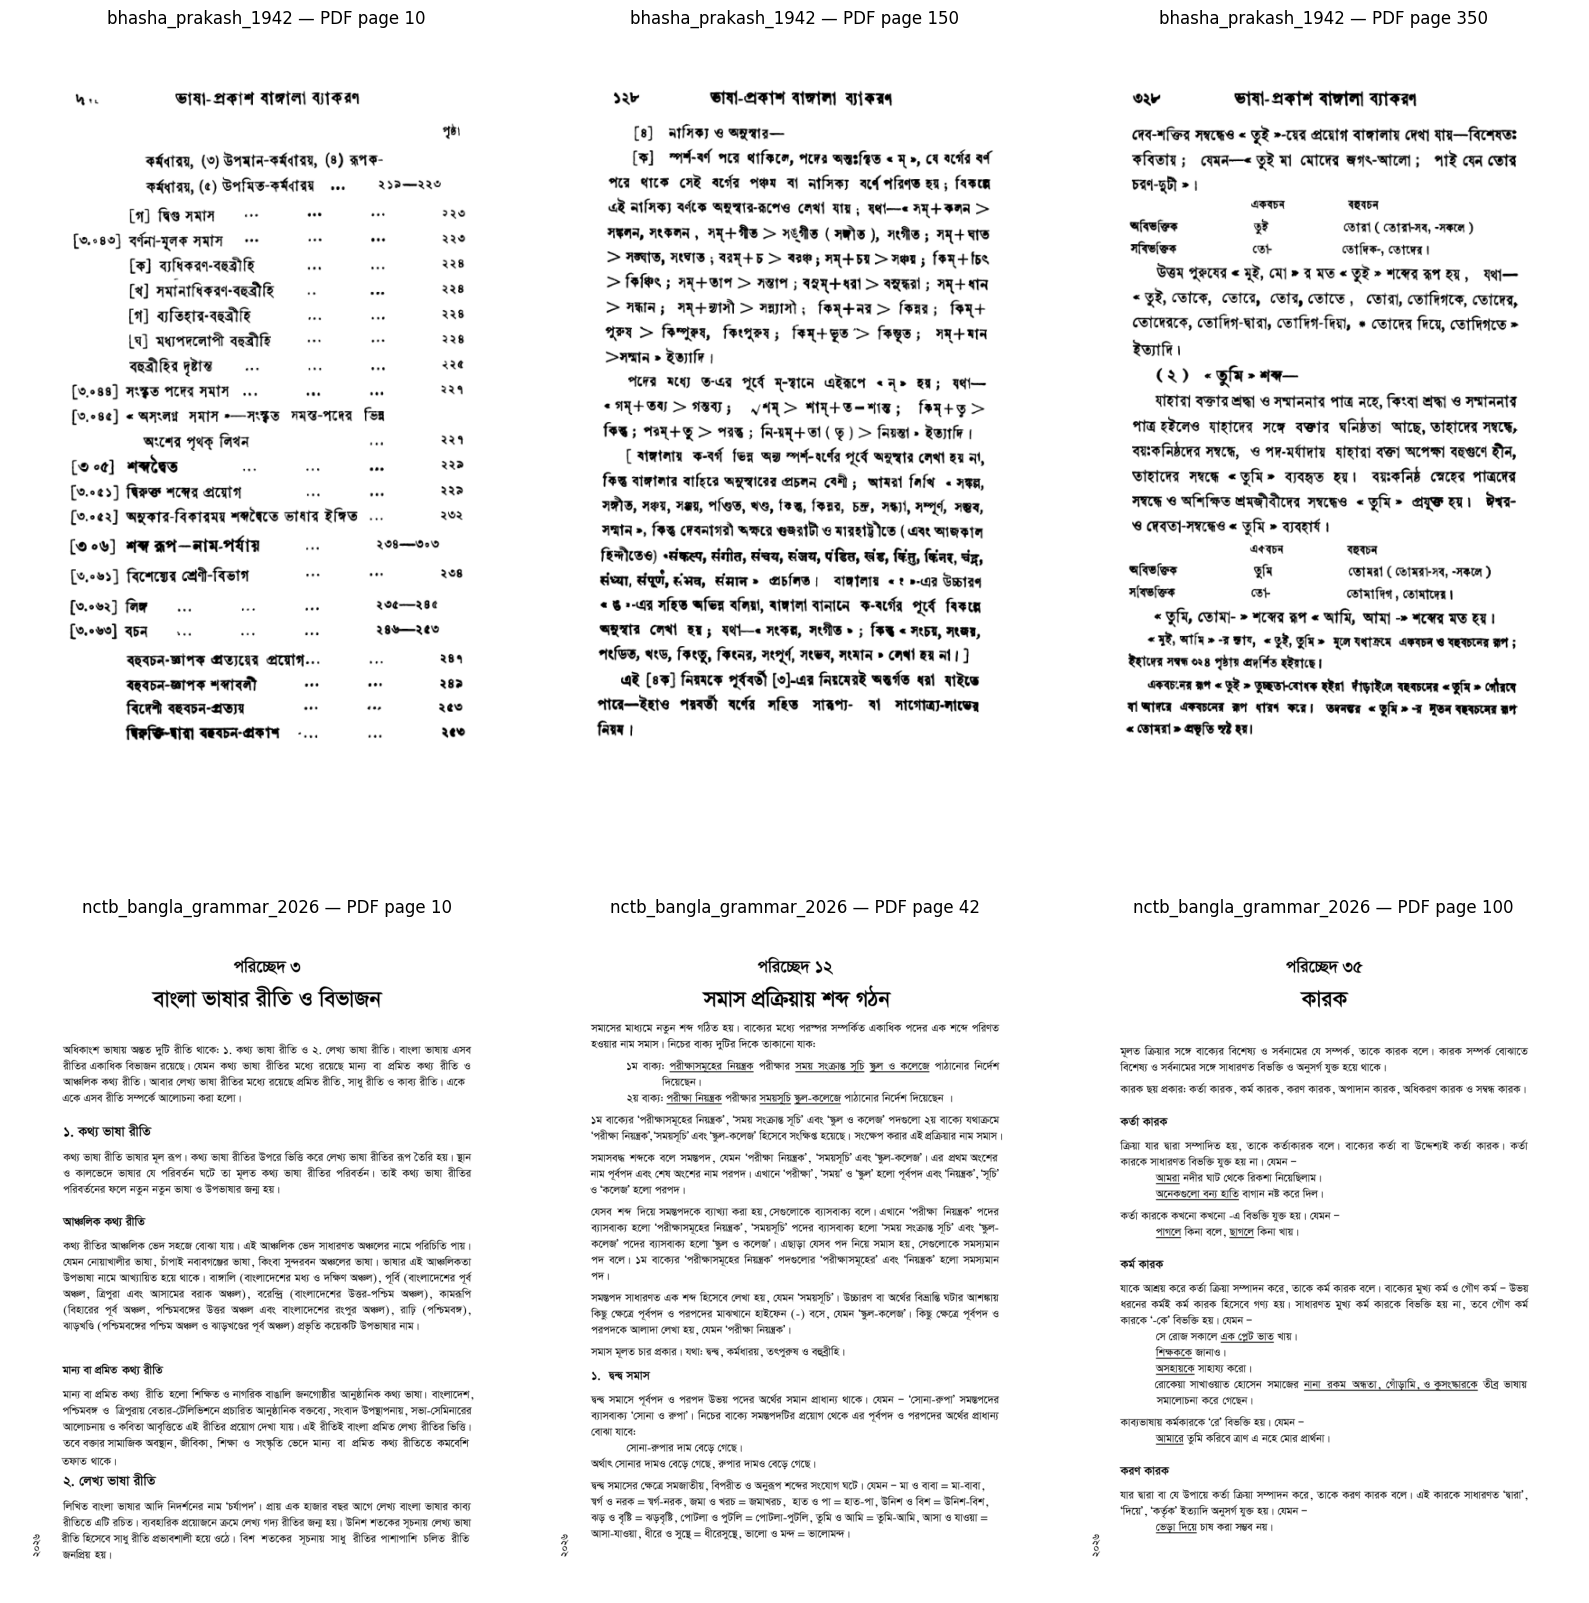

{'doc_id': 'bhasha_prakash_1942', 'pdf_page': 10, 'width_px_at_120dpi': 569, 'height_px_at_120dpi': 846, 'mean_gray': 242.69, 'gray_std': 46.88, 'dark_pixel_fraction_lt_128': 0.0482}
{'doc_id': 'bhasha_prakash_1942', 'pdf_page': 150, 'width_px_at_120dpi': 569, 'height_px_at_120dpi': 846, 'mean_gray': 232.09, 'gray_std': 62.95, 'dark_pixel_fraction_lt_128': 0.0898}
{'doc_id': 'bhasha_prakash_1942', 'pdf_page': 350, 'width_px_at_120dpi': 569, 'height_px_at_120dpi': 846, 'mean_gray': 236.11, 'gray_std': 57.02, 'dark_pixel_fraction_lt_128': 0.0747}
{'doc_id': 'nctb_bangla_grammar_2026', 'pdf_page': 10, 'width_px_at_120dpi': 870, 'height_px_at_120dpi': 1140, 'mean_gray': 241.95, 'gray_std': 44.98, 'dark_pixel_fraction_lt_128': 0.0532}
{'doc_id': 'nctb_bangla_grammar_2026', 'pdf_page': 42, 'width_px_at_120dpi': 870, 'height_px_at_120dpi': 1140, 'mean_gray': 241.77, 'gray_std': 45.02, 'dark_pixel_fraction_lt_128': 0.0533}
{'doc_id': 'nctb_bangla_grammar_2026', 'pdf_page': 100, 'width_px_at_12

In [11]:
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

SAMPLE_PAGES = {
    "bhasha_prakash_1942": [10, 150, 350],
    "nctb_bangla_grammar_2026": [10, 42, 100],
}

figure, axes = plt.subplots(2, 3, figsize=(16, 18))
sample_scan_stats = []

for row_index, (doc_id, page_numbers) in enumerate(SAMPLE_PAGES.items()):
    with fitz.open(corpus_paths[doc_id]) as pdf:
        for column_index, pdf_page_number in enumerate(page_numbers):
            page = pdf.load_page(pdf_page_number - 1)
            pixmap = page.get_pixmap(dpi=120, colorspace=fitz.csGRAY, alpha=False)
            image = Image.open(BytesIO(pixmap.tobytes("png"))).convert("L")
            pixels = np.asarray(image, dtype=np.uint8)
            sample_scan_stats.append(
                {
                    "doc_id": doc_id,
                    "pdf_page": pdf_page_number,
                    "width_px_at_120dpi": image.width,
                    "height_px_at_120dpi": image.height,
                    "mean_gray": round(float(pixels.mean()), 2),
                    "gray_std": round(float(pixels.std()), 2),
                    "dark_pixel_fraction_lt_128": round(float((pixels < 128).mean()), 4),
                }
            )
            axis = axes[row_index, column_index]
            axis.imshow(image, cmap="gray")
            axis.set_title(f"{doc_id} — PDF page {pdf_page_number}")
            axis.axis("off")

plt.tight_layout()
plt.show()

for record in sample_scan_stats:
    print(record)
print("REAL PAGE SAMPLE EDA: PASS")


## 11. Declare the document-level split and corpus revision

In [12]:
split_by_document = {record["doc_id"]: record["split"] for record in corpus_records}
assert split_by_document == {
    "bhasha_prakash_1942": "train",
    "nctb_bangla_grammar_2026": "test",
}
assert len(split_by_document) == len(set(split_by_document))

print("Document-level split:", split_by_document)
print("Validation: one whole-chapter block will be selected from the 1942 train volume after layout inspection.")
print("Limitation: validation shares the train document's era, author, and typography.")
print("Corpus revision: A1 named the 2019 NCTB edition; A2 uses the selected 2026 218-page edition.")
print("The revision must be disclosed in A2 and confirmed with the instructor.")
print("DOCUMENT SPLIT DECLARATION: PASS")


Document-level split: {'bhasha_prakash_1942': 'train', 'nctb_bangla_grammar_2026': 'test'}
Validation: one whole-chapter block will be selected from the 1942 train volume after layout inspection.
Limitation: validation shares the train document's era, author, and typography.
Corpus revision: A1 named the 2019 NCTB edition; A2 uses the selected 2026 218-page edition.
The revision must be disclosed in A2 and confirmed with the instructor.
DOCUMENT SPLIT DECLARATION: PASS


## 12. Export the Phase 1 inventory and summary

In [13]:
phase1_inventory = {
    "status": "pass",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "repository": REPO_URL,
    "branch": REPO_BRANCH,
    "commit": commit_hash,
    "documents": corpus_records,
    "total_pages": total_pages,
    "total_bytes": total_bytes,
    "total_size_mib": round(total_bytes / (1024 * 1024), 2),
    "word_count": None,
    "word_count_status": "pending measured OCR in Phase 6",
    "geometry": geometry_records,
    "sample_scan_statistics": sample_scan_stats,
    "split_by_document": split_by_document,
    "corpus_revision_from_a1": "2019 NCTB edition replaced by selected 2026 218-page edition",
}

inventory_path = ARTIFACT_DIR / "phase1_corpus_inventory.json"
inventory_path.write_text(
    json.dumps(phase1_inventory, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

summary_lines = [
    "# Phase 1 corpus summary",
    "",
    f"- Tested repository commit: `{commit_hash}`",
    f"- Documents: {len(corpus_records)}",
    f"- Raw pages: {total_pages}",
    f"- Source size: {total_bytes:,} bytes ({total_bytes / (1024**2):.2f} MiB)",
    "- Usable OCR words: pending Phase 6",
    "- Split: 1942 volume train; 2026 NCTB volume test; whole-chapter validation block pending",
    "- Corpus revision: A1's 2019 NCTB edition was replaced by the selected 2026 edition",
]
summary_path = ARTIFACT_DIR / "phase1_corpus_summary.md"
summary_path.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")

print(inventory_path.read_text(encoding="utf-8"))
print("Exported:", inventory_path)
print("Exported:", summary_path)
print("PHASE 1 CORPUS INVENTORY: PASS")


{
  "status": "pass",
  "generated_at_utc": "2026-08-10T08:03:22.039283+00:00",
  "repository": "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git",
  "branch": "fahim",
  "commit": "bbe2cdebb9208469a4cdf62cda8e400d2d286e98",
  "documents": [
    {
      "doc_id": "bhasha_prakash_1942",
      "filename": "bhasha_prakash_1942.pdf",
      "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
      "year": 1942,
      "split": "train",
      "pages": 565,
      "bytes": 26715873,
      "size_mib": 25.48,
      "sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b"
    },
    {
      "doc_id": "nctb_bangla_grammar_2026",
      "filename": "nctb_bangla_grammar.pdf",
      "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf",
      "year": 2026,
      "split": "test",
      "pages": 218,
      "bytes": 143145319,
      "size_mib": 136.51,
      "sha256": "3cb900fb1ce51bb91e13e41d43c51d98260a29ffffbed5632b0adee13064

## Phase 1 result and remaining gate

Phase 1's reproducible corpus identity/EDA work is complete when all cells show PASS and a Kaggle version is saved with outputs. Download the executed notebook and the two files under `/kaggle/working/artifacts`.

Two values intentionally remain open:

1. the exact usable word count, which must come from measured OCR in Phase 6 rather than a PDF text layer;
2. the exact validation chapter block, which is selected after layout inspection while remaining entirely inside the 1942 train document.

The team must also disclose/confirm the change from A1's 2019 NCTB edition to the 2026 edition.

# Phase 2 — Reproducible Kaggle runtime

This phase proves that paths, small/full modes, package versions, random seeds, GPU details, and generated-artifact locations are explicit and repeatable. It does not run OCR or build the index yet.

## 13. Capture and check the complete runtime identity

In [ ]:
import importlib.metadata as package_metadata
import shutil

TRACKED_DISTRIBUTIONS = [
    "torch",
    "numpy",
    "pydantic",
    "pydantic-settings",
    "PyYAML",
    "PyMuPDF",
    "Pillow",
    "pytest",
    "ruff",
    "black",
]

installed_versions = {}
for distribution in TRACKED_DISTRIBUTIONS:
    try:
        installed_versions[distribution] = package_metadata.version(distribution)
    except package_metadata.PackageNotFoundError:
        installed_versions[distribution] = None

gpu_records = []
if torch.cuda.is_available():
    for gpu_index in range(torch.cuda.device_count()):
        properties = torch.cuda.get_device_properties(gpu_index)
        gpu_records.append(
            {
                "index": gpu_index,
                "name": properties.name,
                "total_memory_gib": round(properties.total_memory / (1024**3), 2),
                "compute_capability": f"{properties.major}.{properties.minor}",
            }
        )

disk_usage = shutil.disk_usage("/kaggle/working")
runtime_identity = {
    "python": sys.version.replace("\n", " "),
    "platform": platform.platform(),
    "repository_commit": commit_hash,
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "gpus": gpu_records,
    "working_disk_free_gib": round(disk_usage.free / (1024**3), 2),
    "packages": installed_versions,
}

assert sys.version_info[:2] in {(3, 11), (3, 12)}
assert runtime_identity["cuda_available"], "Select a Kaggle GPU accelerator before running A2"
assert gpu_records, "At least one visible GPU is required for the selected Kaggle runtime"
assert all(installed_versions[name] is not None for name in TRACKED_DISTRIBUTIONS)

print(json.dumps(runtime_identity, ensure_ascii=False, indent=2))
print("RUNTIME IDENTITY: PASS")


## 14. Validate portable paths and small/full modes

In [ ]:
os.environ["DOC_AGENT_INPUT_ROOT"] = str(KAGGLE_INPUT)
os.environ["DOC_AGENT_DATA_DIR"] = str(REPO_DIR / "data" / "raw")
os.environ["DOC_AGENT_ARTIFACT_DIR"] = str(ARTIFACT_DIR)
os.environ["DOC_AGENT_RUN_MODE"] = "small"
os.environ["DOC_AGENT_SMALL_MAX_PAGES"] = "20"

from doc_agent.settings import Settings

small_runtime = Settings(_env_file=None)
small_runtime.ensure_writable_dirs()
assert small_runtime.input_root == KAGGLE_INPUT
assert small_runtime.data_dir == REPO_DIR / "data" / "raw"
assert small_runtime.artifact_dir == ARTIFACT_DIR
assert small_runtime.run_mode == "small"
assert small_runtime.page_limit == 20
assert small_runtime.data_dir.is_dir()
assert small_runtime.artifact_dir.is_dir()

os.environ["DOC_AGENT_RUN_MODE"] = "full"
full_runtime = Settings(_env_file=None)
assert full_runtime.run_mode == "full"
assert full_runtime.page_limit is None

# Continue notebook development in safe small mode.
os.environ["DOC_AGENT_RUN_MODE"] = "small"

print("Small mode page limit per document:", small_runtime.page_limit)
print("Full mode page limit per document:", full_runtime.page_limit)
print("Input root (read only):", small_runtime.input_root)
print("Generated data directory:", small_runtime.data_dir)
print("Artifact directory:", small_runtime.artifact_dir)
print("PORTABLE PATHS AND MODES: PASS")


## 15. Show exactly what small and full mode will process

In [ ]:
mode_plan = []
for record in corpus_records:
    mode_plan.append(
        {
            "doc_id": record["doc_id"],
            "available_pages": record["pages"],
            "small_mode_pages": min(record["pages"], small_runtime.page_limit or record["pages"]),
            "full_mode_pages": record["pages"],
        }
    )

small_total = sum(record["small_mode_pages"] for record in mode_plan)
full_total = sum(record["full_mode_pages"] for record in mode_plan)
assert small_total == 40
assert full_total == 783

print(json.dumps(mode_plan, ensure_ascii=False, indent=2))
print(f"Small mode total: {small_total} pages")
print(f"Full mode total: {full_total} pages")
print("SMALL/FULL WORK PLAN: PASS")


## 16. Prove deterministic random seeds

In [ ]:
import random
import runpy

import numpy as np

seed_namespace = runpy.run_path(str(REPO_DIR / "scripts" / "set_seed.py"))
set_seed = seed_namespace["set_seed"]
seed_value = int(cfg["seed"])

first_seed_state = set_seed(seed_value)
first_values = {
    "python": [random.random() for _ in range(3)],
    "numpy": np.random.random(3).tolist(),
    "torch": torch.rand(3).cpu().tolist(),
}

second_seed_state = set_seed(seed_value)
second_values = {
    "python": [random.random() for _ in range(3)],
    "numpy": np.random.random(3).tolist(),
    "torch": torch.rand(3).cpu().tolist(),
}

assert first_values == second_values
assert first_seed_state == second_seed_state
assert first_seed_state["deterministic_algorithms"]

print("Seed state:", first_seed_state)
print("Repeated values:", first_values)
print("DETERMINISTIC SEED TEST: PASS")


## 17. Run the Phase 2 configuration tests

In [ ]:
test_result = run_command(
    [sys.executable, "-m", "pytest", "tests/test_data.py", "-q"],
    cwd=REPO_DIR,
)
assert "3 passed" in test_result.stdout
print("PHASE 2 CONFIGURATION TESTS: PASS")


## 18. Export the reproducibility snapshot

In [ ]:
def sha256_path(path):
    return file_sha256(Path(path))


phase2_snapshot = {
    "status": "pass",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "runtime": runtime_identity,
    "paths": {
        "input_root": str(small_runtime.input_root),
        "data_dir": str(small_runtime.data_dir),
        "artifact_dir": str(small_runtime.artifact_dir),
    },
    "modes": {
        "small_max_pages_per_document": small_runtime.page_limit,
        "small_total_pages": small_total,
        "full_total_pages": full_total,
    },
    "seed": first_seed_state,
    "file_hashes": {
        "pyproject.toml": sha256_path(REPO_DIR / "pyproject.toml"),
        "requirements.lock": sha256_path(REPO_DIR / "requirements.lock"),
        "configs/config.yaml": sha256_path(REPO_DIR / "configs" / "config.yaml"),
    },
}

phase2_path = ARTIFACT_DIR / "phase2_runtime_snapshot.json"
phase2_path.write_text(
    json.dumps(phase2_snapshot, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

snapshot_lines = [
    f"{name}=={version}"
    for name, version in sorted(installed_versions.items())
    if version is not None
]
requirements_snapshot_path = ARTIFACT_DIR / "phase2_requirements_snapshot.txt"
requirements_snapshot_path.write_text("\n".join(snapshot_lines) + "\n", encoding="utf-8")

print(phase2_path.read_text(encoding="utf-8"))
print("Exported:", phase2_path)
print("Exported:", requirements_snapshot_path)
print("PHASE 2 REPRODUCIBILITY SNAPSHOT: PASS")


## Phase 2 result

Phase 2 is complete when Cells 13–18 all report PASS in a saved Kaggle version. The run must record the repository commit, Python/PyTorch/CUDA/GPU versions, installed bootstrap packages, portable paths, a 40-page small mode, a 783-page full mode, deterministic repeated random values, three passing configuration tests, and the exported runtime snapshot.

OCR/model-specific packages are deliberately not selected here; they are pinned later only after the Phase 6/7 experiments choose them.